In [30]:
## LINK SHARED GOOGLE DRIVE
## Useful for the metadata nad .pth files, as well as saving downloads
from google.colab import drive
drive.mount('/content/drive')

import os

# Data Paths
SHARED_ROOT = "/content/drive/Shared drives/NPB 136 -- EYEBROW PIERCINGS"
STORAGE_FOLDER  = os.path.join(SHARED_ROOT, "Project File Storage")
# embeddings1: first run with no normalization
# embeddings2: 2nd run with naive normalization
EMBEDDINGS_FOLDER = os.path.join(STORAGE_FOLDER, "Embeddings4")
os.makedirs(EMBEDDINGS_FOLDER, exist_ok=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [31]:
import torch

checkpoint = torch.load(os.path.join(EMBEDDINGS_FOLDER, "embeddings.pt"))
features      = checkpoint["features"]       # (300, 1024)
labels        = checkpoint["labels"]         # (300,)
patient_codes = checkpoint["patient_codes"]  # list of strings

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


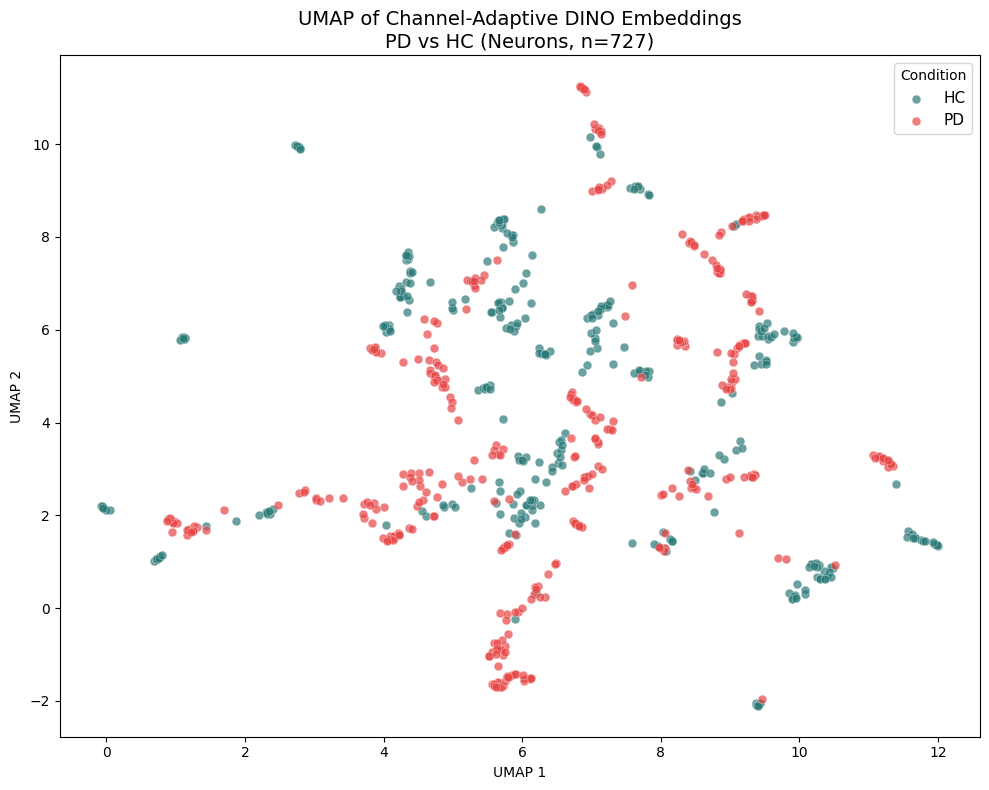

In [32]:
import umap
import numpy as np
import matplotlib.pyplot as plt

# Fit UMAP
reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
embedding_2d = reducer.fit_transform(features)       # (300, 2)

# Plot
fig, ax = plt.subplots(figsize=(10, 8))

colors = {1: "#e84545", 0: "#2b7a78"}
labels_str = {1: "PD", 0: "HC"}

for label_val in [0, 1]:
    mask = labels == label_val
    ax.scatter(
        embedding_2d[mask, 0],
        embedding_2d[mask, 1],
        c=colors[label_val],
        label=labels_str[label_val],
        alpha=0.7,
        s=40,
        edgecolors="white",
        linewidths=0.3
    )

ax.set_title(f"UMAP of Channel-Adaptive DINO Embeddings\nPD vs HC (Neurons, n={len(checkpoint["features"])})", fontsize=14)
ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")
ax.legend(title="Condition", fontsize=11)
plt.tight_layout()
plt.show()

In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

X = features      # (300, 1024)
y = labels        # (300,)

# Scale features — important for linear models on embedding spaces
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Stratified 5-fold so each fold has balanced PD/HC
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, C=1.0),
    "Logistic Regression (C=0.1)": LogisticRegression(max_iter=1000, C=0.1),
    "Linear SVM": LinearSVC(max_iter=2000, C=1.0),
}

print("5-Fold Cross Validation Results")
print("=" * 50)
results = {}
for name, clf in models.items():
    scores = cross_validate(clf, X_scaled, y, cv=cv,
                            scoring=["accuracy", "f1", "roc_auc"],
                            return_train_score=True)
    results[name] = scores
    print(f"\n{name}")
    print(f"  Train Accuracy: {scores['train_accuracy'].mean():.3f} ± {scores['train_accuracy'].std():.3f}")
    print(f"  Val Accuracy:   {scores['test_accuracy'].mean():.3f} ± {scores['test_accuracy'].std():.3f}")
    print(f"  Val F1:         {scores['test_f1'].mean():.3f} ± {scores['test_f1'].std():.3f}")
    print(f"  Val AUC-ROC:    {scores['test_roc_auc'].mean():.3f} ± {scores['test_roc_auc'].std():.3f}")

# Detailed report on best model using last fold's split for confusion matrix
print("\n\nDetailed Report — Logistic Regression")
print("=" * 50)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, stratify=y, random_state=42)

best_clf = LogisticRegression(max_iter=1000, C=1.0).fit(X_train, y_train)
y_pred = best_clf.predict(X_test)

print(classification_report(y_test, y_pred, target_names=["HC", "PD"]))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

5-Fold Cross Validation Results

Logistic Regression
  Train Accuracy: 1.000 ± 0.000
  Val Accuracy:   0.882 ± 0.027
  Val F1:         0.885 ± 0.028
  Val AUC-ROC:    0.957 ± 0.010

Logistic Regression (C=0.1)
  Train Accuracy: 0.966 ± 0.004
  Val Accuracy:   0.875 ± 0.018
  Val F1:         0.880 ± 0.019
  Val AUC-ROC:    0.950 ± 0.015


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(



Linear SVM
  Train Accuracy: 1.000 ± 0.000
  Val Accuracy:   0.878 ± 0.020
  Val F1:         0.882 ± 0.021
  Val AUC-ROC:    0.952 ± 0.012


Detailed Report — Logistic Regression
              precision    recall  f1-score   support

          HC       0.89      0.84      0.87        70
          PD       0.86      0.91      0.88        76

    accuracy                           0.88       146
   macro avg       0.88      0.88      0.88       146
weighted avg       0.88      0.88      0.88       146

Confusion Matrix:
[[59 11]
 [ 7 69]]


In [34]:
import pandas as pd

df = pd.DataFrame({
    "code":    patient_codes,
    "label":   labels.tolist(),
})

# Extract patient ID (e.g. "PD1", "HC1") from "Neurons/PD/PD1_0001"
df["patient"] = df["code"].apply(lambda x: x.split("/")[2].rsplit("_", 1)[0])

print(df.groupby(["patient", "label"]).size())
print(f"\nUnique patients: {df['patient'].nunique()}")

patient  label
HC1      0        27
HC10     0        27
HC11     0        27
HC12     0        27
HC13     0        27
HC2      0        27
HC3      0        27
HC4      0        27
HC5      0        26
HC6      0        27
HC7      0        27
HC8      0        27
HC9      0        27
PD1      1        27
PD10     1        27
PD11     1        27
PD12     1        27
PD13     1        27
PD14     1        27
PD2      1        27
PD3      1        26
PD4      1        27
PD5      1        27
PD6      1        27
PD7      1        27
PD8      1        27
PD9      1        27
dtype: int64

Unique patients: 27


In [35]:
print("Samples per patient:")
print(df.groupby(["patient", "label"]).size().unstack(fill_value=0))

Samples per patient:
label     0   1
patient        
HC1      27   0
HC10     27   0
HC11     27   0
HC12     27   0
HC13     27   0
HC2      27   0
HC3      27   0
HC4      27   0
HC5      26   0
HC6      27   0
HC7      27   0
HC8      27   0
HC9      27   0
PD1       0  27
PD10      0  27
PD11      0  27
PD12      0  27
PD13      0  27
PD14      0  27
PD2       0  27
PD3       0  26
PD4       0  27
PD5       0  27
PD6       0  27
PD7       0  27
PD8       0  27
PD9       0  27


In [36]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix

# Rebuild df in case it's not in scope
df = pd.DataFrame({
    "code":    patient_codes,
    "label":   labels.tolist(),
})
df["patient"] = df["code"].apply(lambda x: x.split("/")[2].rsplit("_", 1)[0])

X = features.numpy() if hasattr(features, 'numpy') else features
y = np.array(labels.tolist() if hasattr(labels, 'tolist') else labels)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Sort patients correctly by numeric suffix
pd_patients = sorted(df[df["label"]==1]["patient"].unique(),
                     key=lambda x: int(x[2:]))
hc_patients = sorted(df[df["label"]==0]["patient"].unique(),
                     key=lambda x: int(x[2:]))

print(f"PD patients: {pd_patients}")
print(f"HC patients: {hc_patients}")

folds = list(zip(pd_patients, hc_patients))
print(f"\nFold pairings:")
for i, (pd_p, hc_p) in enumerate(folds):
    n_test = df["patient"].isin([pd_p, hc_p]).sum()
    print(f"  Fold {i+1}: hold out {pd_p} + {hc_p}  (n={n_test})")

# Run paired folds
results = []
all_y_true = []
all_y_pred = []
all_y_prob = []

print("\n" + "=" * 55)
for fold_idx, (pd_p, hc_p) in enumerate(folds):
    test_mask  = df["patient"].isin([pd_p, hc_p]).values
    train_mask = ~test_mask

    X_train, y_train = X_scaled[train_mask], y[train_mask]
    X_test,  y_test  = X_scaled[test_mask],  y[test_mask]

    clf = LogisticRegression(max_iter=1000, C=0.1)
    clf.fit(X_train, y_train)

    y_pred = clf.predict(X_test)
    y_prob = clf.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    cm  = confusion_matrix(y_test, y_pred)
    results.append((acc, f1, auc))

    all_y_true.extend(y_test.tolist())
    all_y_pred.extend(y_pred.tolist())
    all_y_prob.extend(y_prob.tolist())

    print(f"\nFold {fold_idx+1} — {pd_p} + {hc_p}  (n_train={train_mask.sum()}, n_test={test_mask.sum()})")
    print(f"  Accuracy: {acc:.3f}  |  F1: {f1:.3f}  |  AUC-ROC: {auc:.3f}")
    print(f"  Confusion matrix (rows=true, cols=pred):")
    print(f"           HC    PD")
    print(f"    HC  {cm[0,0]:5d} {cm[0,1]:5d}")
    print(f"    PD  {cm[1,0]:5d} {cm[1,1]:5d}")

# Aggregate results
accs, f1s, aucs = zip(*results)
print("\n" + "=" * 55)
print("Paired Patient-Held-Out CV — Aggregate")
print("=" * 55)
print(f"  Accuracy: {np.mean(accs):.3f} ± {np.std(accs):.3f}")
print(f"  F1:       {np.mean(f1s):.3f} ± {np.std(f1s):.3f}")
print(f"  AUC-ROC:  {np.mean(aucs):.3f} ± {np.std(aucs):.3f}")

# Pooled confusion matrix across all folds
print("\nPooled Confusion Matrix (all folds):")
cm_total = confusion_matrix(all_y_true, all_y_pred)
print(f"           HC    PD")
print(f"    HC  {cm_total[0,0]:5d} {cm_total[0,1]:5d}")
print(f"    PD  {cm_total[1,0]:5d} {cm_total[1,1]:5d}")
print(f"\n  Pooled Accuracy: {accuracy_score(all_y_true, all_y_pred):.3f}")
print(f"  Pooled AUC-ROC:  {roc_auc_score(all_y_true, all_y_prob):.3f}")

PD patients: ['PD1', 'PD2', 'PD3', 'PD4', 'PD5', 'PD6', 'PD7', 'PD8', 'PD9', 'PD10', 'PD11', 'PD12', 'PD13', 'PD14']
HC patients: ['HC1', 'HC2', 'HC3', 'HC4', 'HC5', 'HC6', 'HC7', 'HC8', 'HC9', 'HC10', 'HC11', 'HC12', 'HC13']

Fold pairings:
  Fold 1: hold out PD1 + HC1  (n=54)
  Fold 2: hold out PD2 + HC2  (n=54)
  Fold 3: hold out PD3 + HC3  (n=53)
  Fold 4: hold out PD4 + HC4  (n=54)
  Fold 5: hold out PD5 + HC5  (n=53)
  Fold 6: hold out PD6 + HC6  (n=54)
  Fold 7: hold out PD7 + HC7  (n=54)
  Fold 8: hold out PD8 + HC8  (n=54)
  Fold 9: hold out PD9 + HC9  (n=54)
  Fold 10: hold out PD10 + HC10  (n=54)
  Fold 11: hold out PD11 + HC11  (n=54)
  Fold 12: hold out PD12 + HC12  (n=54)
  Fold 13: hold out PD13 + HC13  (n=54)


Fold 1 — PD1 + HC1  (n_train=673, n_test=54)
  Accuracy: 0.259  |  F1: 0.333  |  AUC-ROC: 0.257
  Confusion matrix (rows=true, cols=pred):
           HC    PD
    HC      4    23
    PD     17    10

Fold 2 — PD2 + HC2  (n_train=673, n_test=54)
  Accuracy: 0.500 

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/tmp/ipykernel_595/4124354107.py:30: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", len(unique_pats))


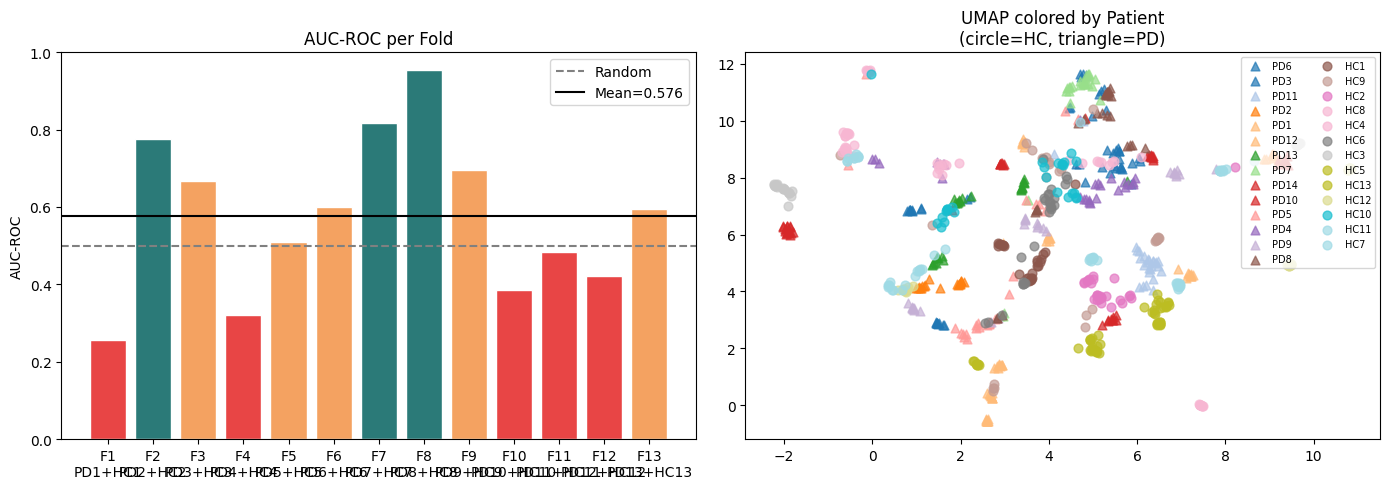

In [37]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Plot per-fold AUC with patient labels to spot outliers
fold_labels = [f"F{i+1}\n{pd_p}+{hc_p}"
               for i, (pd_p, hc_p) in enumerate(folds)]
fold_aucs   = [auc for _, _, auc in results]
fold_accs   = [acc for acc, _, _ in results]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# AUC per fold
colors = ["#e84545" if a < 0.5 else "#f4a261" if a < 0.7 else "#2b7a78"
          for a in fold_aucs]
axes[0].bar(fold_labels, fold_aucs, color=colors, edgecolor="white")
axes[0].axhline(0.5, color="gray", linestyle="--", label="Random")
axes[0].axhline(np.mean(fold_aucs), color="black", linestyle="-",
                label=f"Mean={np.mean(fold_aucs):.3f}")
axes[0].set_title("AUC-ROC per Fold")
axes[0].set_ylabel("AUC-ROC")
axes[0].set_ylim(0, 1)
axes[0].legend()

# Embedding visualization colored by patient to spot batch effects
reducer_check = umap.UMAP(n_components=2, random_state=42)
emb = reducer_check.fit_transform(X_scaled)

patient_list = df["patient"].values
unique_pats  = df["patient"].unique()
cmap = plt.cm.get_cmap("tab20", len(unique_pats))
pat_to_color = {p: cmap(i) for i, p in enumerate(unique_pats)}

for pat in unique_pats:
    mask = patient_list == pat
    label_val = y[mask][0]
    marker = "o" if label_val == 0 else "^"
    axes[1].scatter(emb[mask, 0], emb[mask, 1],
                    color=pat_to_color[pat], marker=marker,
                    alpha=0.7, s=40, label=pat)

axes[1].set_title("UMAP colored by Patient\n(circle=HC, triangle=PD)")
axes[1].legend(fontsize=7, ncol=2, loc="upper right")

plt.tight_layout()
plt.savefig(os.path.join(EMBEDDINGS_FOLDER, "fold_analysis.png"), dpi=150)
plt.show()